<a href="https://colab.research.google.com/github/Mandip-xd/5CS037/blob/main/2548193_MandipGautam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic Data Exploration & Trend Visualization

# 3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)





Importing tool & Loading Data

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
hdi_data = pd.read_csv('/content/Human_Development_Index_Dataset.csv', encoding='latin1')
hdi_data['year'] = pd.to_numeric(hdi_data['year'], errors='coerce')

Task-1. Extracting Latest Year:

In [135]:
print("Available Years:", hdi_data['year'].unique())

hdi_yr22 = hdi_data[hdi_data['year'] == 2022].copy()


Available Years: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


Task-2. Exploring Data

In [136]:
print(hdi_yr22.head(10))
print("Shape:", hdi_yr22.shape)
print(hdi_yr22.dtypes)


     Unnamed: 0 iso3              country  year    hdi  life_expectancy  \
32           33  AFG          Afghanistan  2022  0.462           62.879   
65           66  ALB              Albania  2022  0.789           76.833   
98           99  DZA              Algeria  2022  0.745           77.129   
131         132  AND              Andorra  2022  0.884           83.552   
164         165  AGO               Angola  2022  0.591           61.929   
197         198  ATG  Antigua and Barbuda  2022  0.826           79.236   
230         231  ARG            Argentina  2022  0.849           76.064   
263         264  ARM              Armenia  2022  0.786           73.372   
296         297  AUS            Australia  2022  0.946           83.579   
329         330  AUT              Austria  2022  0.926           82.412   

     pop_millions     hdi_f     hdi_m  life_expec_f  ...  gender_development  \
32      41.128771  0.332443  0.534145        66.213  ...               0.622   
65       2.842

Task-3: Checking for Missing Values & Cleaning Data

In [137]:
hdi_yr22 = hdi_yr22.replace("–", np.nan)

hdi_yr22['hdi'] = pd.to_numeric(hdi_yr22['hdi'], errors='coerce')
hdi_yr22['gross_inc_percap'] = pd.to_numeric(
    hdi_yr22['gross_inc_percap'], errors='coerce'
)

hdi_yr22.drop_duplicates(inplace=True)
hdi_yr22['hdi'] = hdi_yr22['hdi'].fillna(hdi_yr22['hdi'].median())

Task 4: Computing Basic Statistical Analysis

In [138]:
avg_hdi = hdi_yr22['hdi'].mean()
med_hdi = hdi_yr22['hdi'].median()
std_hdi = hdi_yr22['hdi'].std()

top_country = hdi_yr22.loc[hdi_yr22['hdi'].idxmax(), 'country']
low_country = hdi_yr22.loc[hdi_yr22['hdi'].idxmin(), 'country']

print(avg_hdi, med_hdi, std_hdi)
print(top_country, low_country)


0.7230485436893206 0.7395 0.15228924684686668
Switzerland Somalia


Task-5. Filtering Nations and Sorting GNI

In [139]:
top_income = (
    hdi_yr22[hdi_yr22['hdi'] > 0.8]
    .sort_values(by='gross_inc_percap', ascending=False)
    .head(10)
)

print(top_income[['country', 'hdi', 'gross_inc_percap']])


                     country    hdi  gross_inc_percap
3332           Liechtenstein  0.942      146673.24150
4718                   Qatar  0.875       95944.37754
5213               Singapore  0.949       88761.14559
2705                 Ireland  0.950       87467.51391
3398              Luxembourg  0.927       78554.23640
6104    United Arab Emirates  0.937       74103.71494
5609             Switzerland  0.967       69432.78669
4322                  Norway  0.966       69189.76165
6170           United States  0.927       65564.93798
2474  Hong Kong, China (SAR)  0.956       62485.50516


Task 6: HDI Categorization

In [140]:
def hdi_level(val):
    if val < 0.55:
        return "Low"
    elif val < 0.70:
        return "Medium"
    elif val < 0.80:
        return "High"
    else:
        return "Very High"

hdi_yr22['HDI_Level'] = hdi_yr22['hdi'].apply(hdi_level)
hdi_yr22.to_csv("HDI_2022_Classified.csv", index=False)


# 3.2 Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)


Task-1:Multi-Year Extraction

In [141]:
trend_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()
trend_df = trend_df.replace("–", np.nan)

trend_df['hdi'] = pd.to_numeric(trend_df['hdi'], errors='coerce')
trend_df.dropna(subset=['hdi', 'country'], inplace=True)

trend_df.to_csv("HDI_Trend_2020_2022.csv", index=False)


Task-2: Data Cleaing

In [142]:
essential_cols = ['hdi', 'country', 'year']
print("Missing values in essential columns:")
print(hdi_yr22[essential_cols].isnull().sum())




Missing values in essential columns:
hdi        0
country    0
year       0
dtype: int64


In [143]:
hdi_2022_df = hdi_yr22.replace("–", np.nan)
hdi_2022_df['hdi'] = pd.to_numeric(hdi_2022_df['hdi'], errors='coerce')
hdi_2022_df['year'] = pd.to_numeric(hdi_2022_df['year'], errors='coerce')


In [144]:
hdi_2022_df.dropna(subset=['country', 'year'], inplace=True)
hdi_2022_df['hdi'] = hdi_2022_df['hdi'].fillna(hdi_2022_df['hdi'].median())


In [145]:
hdi_2022_df['country'] = (
    hdi_2022_df['country']
    .str.strip()
    .str.title()
)


In [146]:
before = hdi_2022_df.shape[0]
hdi_2022_df.drop_duplicates(inplace=True)
after = hdi_2022_df.shape[0]

print(f"Duplicates removed: {before - after}")


Duplicates removed: 0


In [147]:
print("Remaining missing values:")
print(hdi_2022_df[essential_cols].isnull().sum())

print("Final dataset shape:", hdi_2022_df.shape)


Remaining missing values:
hdi        0
country    0
year       0
dtype: int64
Final dataset shape: (206, 31)


Task-3.Visualizing Data

A. Line Chart (Country-Level)

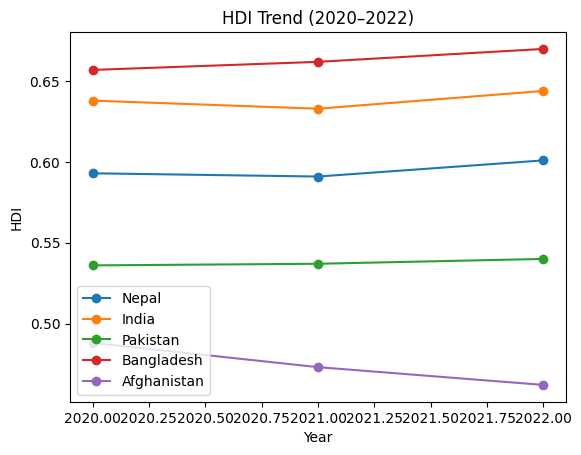

In [148]:
countries_demo = ["Nepal", "India", "Pakistan", "Bangladesh", "Afghanistan"]

plt.figure()
for c in countries_demo:
    temp = trend_df[trend_df['country'] == c]
    plt.plot(temp['year'], temp['hdi'], marker='o', label=c)

plt.title("HDI Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.legend()
plt.show()


B. Generating Visualizations


*– Bar Chart: Average HDI by Region (2020–2022)*

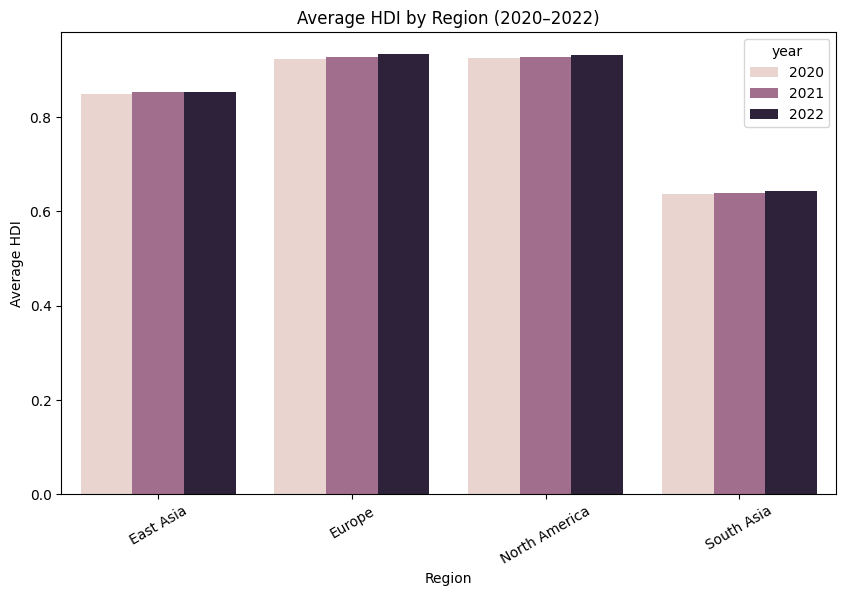

In [149]:
region_map = {
    "Nepal": "South Asia", "India": "South Asia", "Pakistan": "South Asia",
    "Bangladesh": "South Asia", "Sri Lanka": "South Asia", "Bhutan": "South Asia",
    "Maldives": "South Asia", "Afghanistan": "South Asia",

    "China": "East Asia", "Japan": "East Asia", "South Korea": "East Asia",

    "Germany": "Europe", "France": "Europe", "United Kingdom": "Europe",

    "United States": "North America", "Canada": "North America"
}

trend_df['region'] = trend_df['country'].map(region_map)
trend_df = trend_df.dropna(subset=['region'])

region_year_avg = (
    trend_df
    .groupby(['region', 'year'])['hdi']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_year_avg, x='region', y='hdi', hue='year')
plt.xlabel("Region")
plt.ylabel("Average HDI")
plt.title("Average HDI by Region (2020–2022)")
plt.xticks(rotation=30)
plt.show()


*– Box Plot: HDI Distribution for 2020, 2021, and 2022*

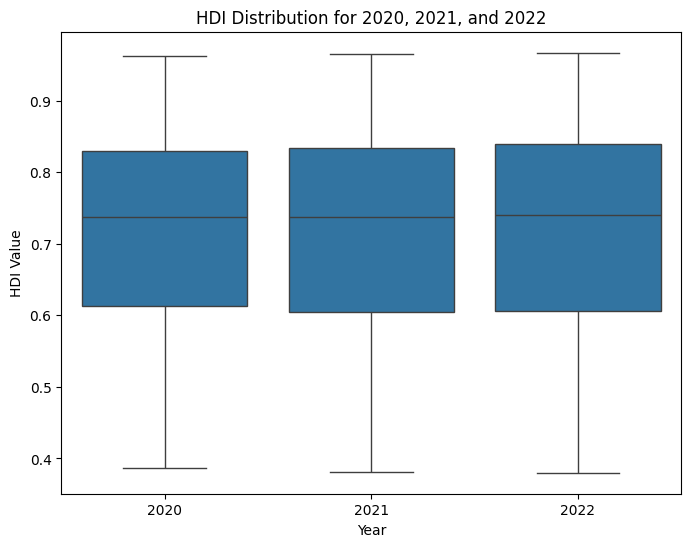

In [150]:
hdi_box_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()

hdi_box_df = hdi_box_df.replace("–", np.nan)
hdi_box_df['hdi'] = pd.to_numeric(hdi_box_df['hdi'], errors='coerce')
hdi_box_df.dropna(subset=['hdi', 'year'], inplace=True)

plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='hdi', data=hdi_box_df)
plt.xlabel("Year")
plt.ylabel("HDI Value")
plt.title("HDI Distribution for 2020, 2021, and 2022")
plt.show()


*Scatter Plot: HDI vs. GNI per Capita*

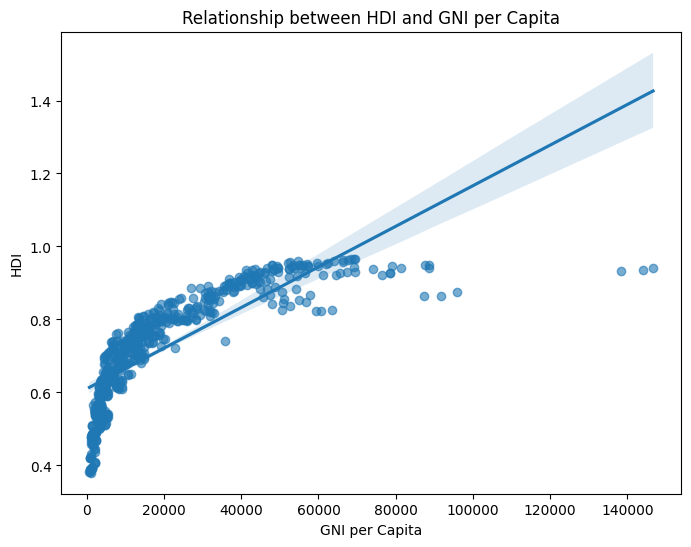

In [151]:
if 'gross_inc_percap' in hdi_data.columns:
    scatter_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()
    scatter_df = scatter_df.replace("–", np.nan)

    scatter_df['hdi'] = pd.to_numeric(scatter_df['hdi'], errors='coerce')
    scatter_df['gross_inc_percap'] = pd.to_numeric(
        scatter_df['gross_inc_percap'], errors='coerce'
    )

    scatter_df.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

    plt.figure(figsize=(8, 6))
    sns.regplot(
        x='gross_inc_percap',
        y='hdi',
        data=scatter_df,
        scatter_kws={'alpha': 0.6}
    )
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.title("Relationship between HDI and GNI per Capita")
    plt.show()
else:
    print("GNI per Capita variable not available in the dataset.")


4. Short Analysis Questions:

 Q1.Which countries show the greatest improvement in HDI from 2020 to 2022?

Ans. Andorra shows one of the most notable improvement , it went from 0.843 hdi in 2020 to 0.884 by 2022. On second place Alegria also saw a improvement from 0.730 in 2020 to 0.745 in 2022.

Q2.Did any countries experience a decline in HDI? Provide possible reasons.

Ans. Yes Afghanistan saw a significant decline , with its HDI dropiing form 0.488 in 2020 to 0.462 in 2022. The decline is linked to education and health aspect. Egypt also a marginal decline from 0.729 in 2020 to 0.728 in 2022 , the possible reason for such decline can blamed to covid and political instality which affected GNI.

Q3.Which region has the highest and lowest average HDI across these three years?

Ans.Europe and Central Asia typically has the highest avg HDI and Sub-Saharan Afican region holds lowest aerage HDI.

Q4.Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during
this period.

Ans. Global events like COVID-19 had severe impact in three aspects of HDI, Health, Education and Economy.
The pandemic reduced the earning as the whole world went into lockdown. Education institutes were shut down and virus claimed life of millions of people.

4 Problem 2
# Advanced HDI Exploration

Task 1. Creating South Asia Subset

In [152]:
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

hdi_south_asia = hdi_data[hdi_data['country'].isin(south_asia_countries)].copy()

hdi_south_asia.to_csv("HDI_SouthAsia.csv", index=False)

print("South Asia subset saved as 'HDI_SouthAsia.csv'")


South Asia subset saved as 'HDI_SouthAsia.csv'


Task-2. Compositing Development Score

In [153]:
sa_latest = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

sa_latest = sa_latest.replace("–", np.nan)

sa_latest['life_expectancy'] = pd.to_numeric(
    sa_latest['life_expectancy'], errors='coerce'
)
sa_latest['gross_inc_percap'] = pd.to_numeric(
    sa_latest['gross_inc_percap'], errors='coerce'
)
sa_latest['hdi'] = pd.to_numeric(
    sa_latest['hdi'], errors='coerce'
)

sa_latest.dropna(
    subset=['life_expectancy', 'gross_inc_percap', 'hdi'],
    inplace=True
)

sa_latest['Composite Score'] = (
    0.30 * sa_latest['life_expectancy'] +
    0.30 * sa_latest['gross_inc_percap']
)


In [154]:
composite_rank = sa_latest.sort_values(
    by='Composite Score', ascending=False
)

print(composite_rank[['country', 'Composite Score', 'hdi']])


          country  Composite Score    hdi
3530     Maldives      5678.289357  0.762
5477    Sri Lanka      3592.832541  0.780
659        Bhutan      3209.130864  0.681
2573        India      2105.481239  0.644
461    Bangladesh      1975.446053  0.670
4388     Pakistan      1632.210427  0.540
4091        Nepal      1228.811605  0.601
32    Afghanistan       419.425420  0.462


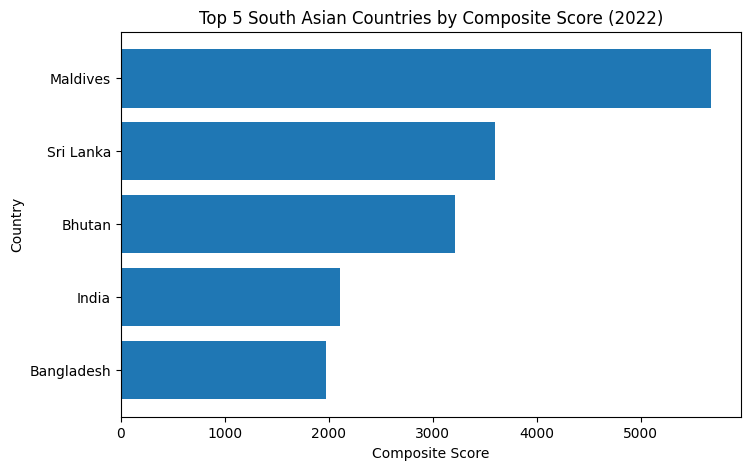

In [155]:
top5_composite = composite_rank.head(5)

plt.figure(figsize=(8, 5))
plt.barh(
    top5_composite['country'],
    top5_composite['Composite Score']
)
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.title("Top 5 South Asian Countries by Composite Score (2022)")
plt.gca().invert_yaxis()
plt.show()


Task-3. Detecting Outlier

In [156]:
sa_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

sa_2022 = sa_2022.replace("–", np.nan)

sa_2022['hdi'] = pd.to_numeric(
sa_2022['hdi'], errors='coerce'
)
sa_2022['gross_inc_percap'] = pd.to_numeric(
sa_2022['gross_inc_percap'], errors='coerce'
)

sa_2022.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

Q1_hdi = sa_2022['hdi'].quantile(0.25)
Q3_hdi = sa_2022['hdi'].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

Q1_gni = sa_2022['gross_inc_percap'].quantile(0.25)
Q3_gni = sa_2022['gross_inc_percap'].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

outliers_sa = sa_2022[
    (sa_2022['hdi'] < Q1_hdi - 1.5 * IQR_hdi) |
    (sa_2022['hdi'] > Q3_hdi + 1.5 * IQR_hdi) |
    (sa_2022['gross_inc_percap'] < Q1_gni - 1.5 * IQR_gni) |
    (sa_2022['gross_inc_percap'] > Q3_gni + 1.5 * IQR_gni)
]

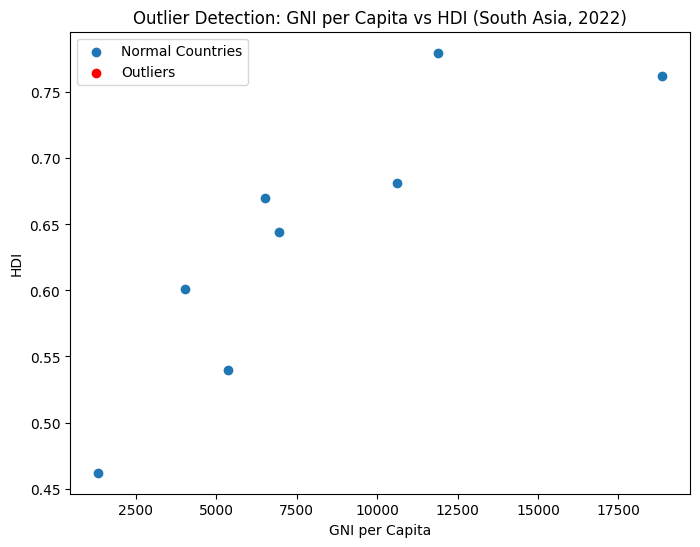

In [157]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sa_2022['gross_inc_percap'],
    sa_2022['hdi'],
    label='Normal Countries'
)

plt.scatter(
    outliers_sa['gross_inc_percap'],
    outliers_sa['hdi'],
    color='red',
    label='Outliers'
)

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Outlier Detection: GNI per Capita vs HDI (South Asia, 2022)")
plt.legend()
plt.show()


The scatter plot shows that most South Asian countries have a positive relationship between GNI per capita and HDI, but some countries appear as outliers when income does not match human development. Countries with high GNI but low HDI often face income inequality, weak education and healthcare systems, or governance issues. On the other hand, countries with low GNI but relatively high HDI benefit from strong public services, effective social policies, and better education outcomes. These outliers clearly show that income alone does not fully explain human development, highlighting the multidimensional nature of HDI.

4. Exploring Metric Relationships:


In [158]:
metric_df = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

metric_df = metric_df.replace("–", np.nan)

metric_df['hdi'] = pd.to_numeric(metric_df['hdi'], errors='coerce')
metric_df['gender_development'] = pd.to_numeric(
    metric_df['gender_development'], errors='coerce'
)
metric_df['life_expectancy'] = pd.to_numeric(
    metric_df['life_expectancy'], errors='coerce'
)

metric_df.dropna(
    subset=['hdi', 'gender_development', 'life_expectancy'],
    inplace=True
)

In [159]:
corr_gender_hdi = metric_df['gender_development'].corr(metric_df['hdi'])
corr_life_hdi = metric_df['life_expectancy'].corr(metric_df['hdi'])

print("Pearson Correlation (Gender Development vs HDI):", corr_gender_hdi)
print("Pearson Correlation (Life Expectancy vs HDI):", corr_life_hdi)


Pearson Correlation (Gender Development vs HDI): 0.884759535448765
Pearson Correlation (Life Expectancy vs HDI): 0.9281974040239385


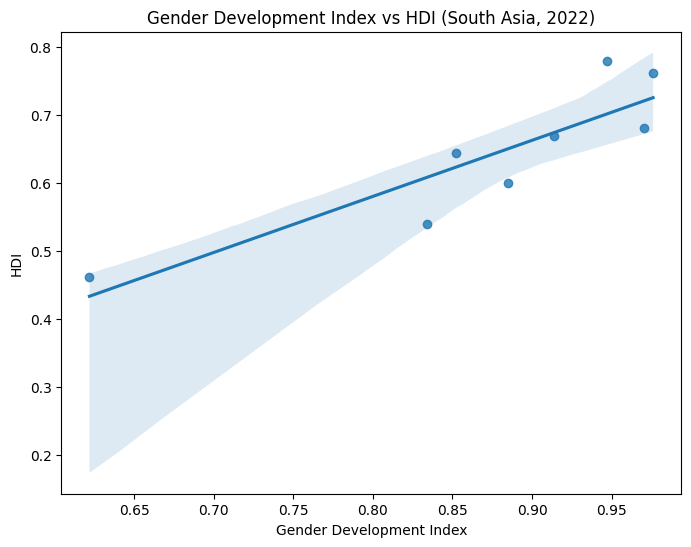

In [160]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='gender_development',
    y='hdi',
    data=metric_df
)
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.title("Gender Development Index vs HDI (South Asia, 2022)")
plt.show()


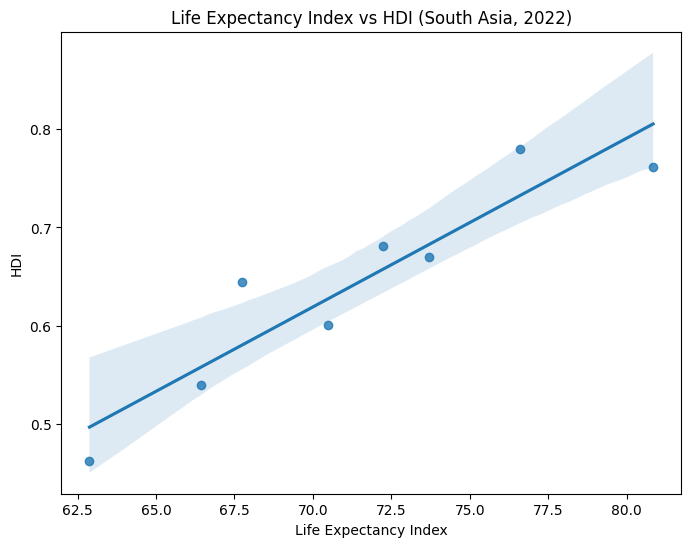

In [161]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='life_expectancy',
    y='hdi',
    data=metric_df
)
plt.xlabel("Life Expectancy Index")
plt.ylabel("HDI")
plt.title("Life Expectancy Index vs HDI (South Asia, 2022)")
plt.show()


The Life Expectancy Index shows a stronger positive correlation with HDI than the Gender Development Index. The scatter plot for life expectancy has a clear upward trend, meaning countries with higher life expectancy usually have higher HDI values. In contrast, the Gender Development Index also shows a positive relationship with HDI, but the data points are more scattered, indicating a weaker link. This suggests that although gender equality supports human development, health outcomes have a more important role in explaining HDI differences among South Asian countries.


Task-5. Gap Analysis

In [162]:
gap_df = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

gap_df = gap_df.replace("–", np.nan)

gap_df['gross_inc_percap'] = pd.to_numeric(
    gap_df['gross_inc_percap'], errors='coerce'
)
gap_df['hdi'] = pd.to_numeric(
    gap_df['hdi'], errors='coerce'
)

gap_df.dropna(subset=['gross_inc_percap', 'hdi'], inplace=True)

gap_df['GNI_HDI_Gap'] = gap_df['gross_inc_percap'] - gap_df['hdi']


In [163]:
gap_desc = gap_df.sort_values(by='GNI_HDI_Gap', ascending=False)
print(gap_desc[['country', 'GNI_HDI_Gap']])


          country   GNI_HDI_Gap
3530     Maldives  18846.030190
5477    Sri Lanka  11898.718470
659        Bhutan  10624.192880
2573        India   6949.882798
461    Bangladesh   6510.452178
4388     Pakistan   5373.730423
4091        Nepal   4024.953685
32    Afghanistan   1334.743733


In [164]:
gap_asc = gap_df.sort_values(by='GNI_HDI_Gap', ascending=True)
print(gap_asc[['country', 'GNI_HDI_Gap']])


          country   GNI_HDI_Gap
32    Afghanistan   1334.743733
4091        Nepal   4024.953685
4388     Pakistan   5373.730423
461    Bangladesh   6510.452178
2573        India   6949.882798
659        Bhutan  10624.192880
5477    Sri Lanka  11898.718470
3530     Maldives  18846.030190


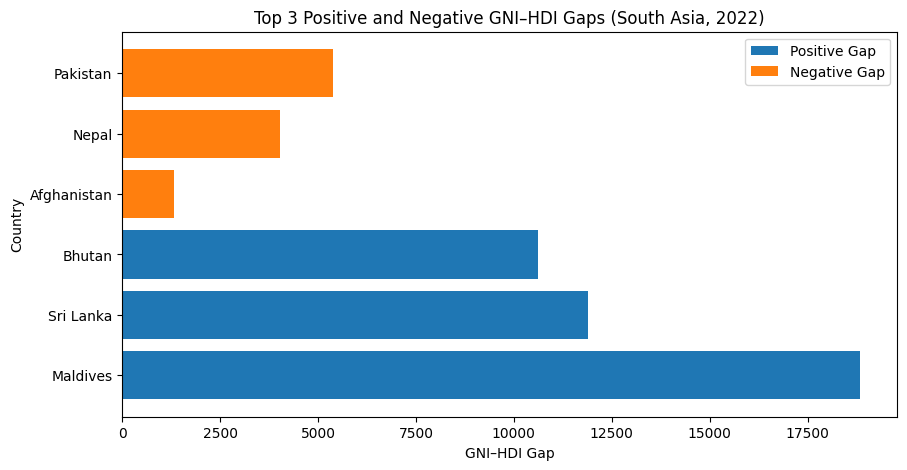

In [165]:
top_positive = gap_desc.head(3)
top_negative = gap_asc.head(3)

plt.figure(figsize=(10, 5))

plt.barh(
    top_positive['country'],
    top_positive['GNI_HDI_Gap'],
    label='Positive Gap'
)

plt.barh(
    top_negative['country'],
    top_negative['GNI_HDI_Gap'],
    label='Negative Gap'
)

plt.xlabel("GNI–HDI Gap")
plt.ylabel("Country")
plt.title("Top 3 Positive and Negative GNI–HDI Gaps (South Asia, 2022)")
plt.legend()
plt.show()


5 Problem 3
# Comparative Regional Analysis: South Asia vs Middle East


1. Create Middle East Subset:

In [166]:
problem1b_df = pd.read_csv("HDI_Trend_2020_2022.csv")

south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

south_asia_2020_2022 = problem1b_df[
    problem1b_df['country'].isin(south_asia_countries)
].copy()

middle_east_2020_2022 = problem1b_df[
    problem1b_df['country'].isin(middle_east_countries)
].copy()

south_asia_2020_2022.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_2020_2022.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

print("Files saved: HDI_SouthAsia_2020_2022.csv and HDI_MiddleEast_2020_2022.csv")

Files saved: HDI_SouthAsia_2020_2022.csv and HDI_MiddleEast_2020_2022.csv


2. Descriptive Statistics:

In [167]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_mean = sa_df['hdi'].mean()
sa_std = sa_df['hdi'].std()

me_mean = me_df['hdi'].mean()
me_std = me_df['hdi'].std()

print("South Asia HDI Mean:", sa_mean)
print("South Asia HDI Std Dev:", sa_std)

print("Middle East HDI Mean:", me_mean)
print("Middle East HDI Std Dev:", me_std)


South Asia HDI Mean: 0.6395833333333333
South Asia HDI Std Dev: 0.09827331747496995
Middle East HDI Mean: 0.7889090909090909
Middle East HDI Std Dev: 0.14129476362297624


3. Top and Bottom Performers:


In [168]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_avg = sa_df.groupby('country')['hdi'].mean().reset_index()
me_avg = me_df.groupby('country')['hdi'].mean().reset_index()

sa_top3 = sa_avg.sort_values(by='hdi', ascending=False).head(3)
sa_bottom3 = sa_avg.sort_values(by='hdi', ascending=True).head(3)

me_top3 = me_avg.sort_values(by='hdi', ascending=False).head(3)
me_bottom3 = me_avg.sort_values(by='hdi', ascending=True).head(3)


In [169]:
compare_df = pd.concat([
    sa_top3.assign(region='South Asia', type='Top'),
    sa_bottom3.assign(region='South Asia', type='Bottom'),
    me_top3.assign(region='Middle East', type='Top'),
    me_bottom3.assign(region='Middle East', type='Bottom')
])


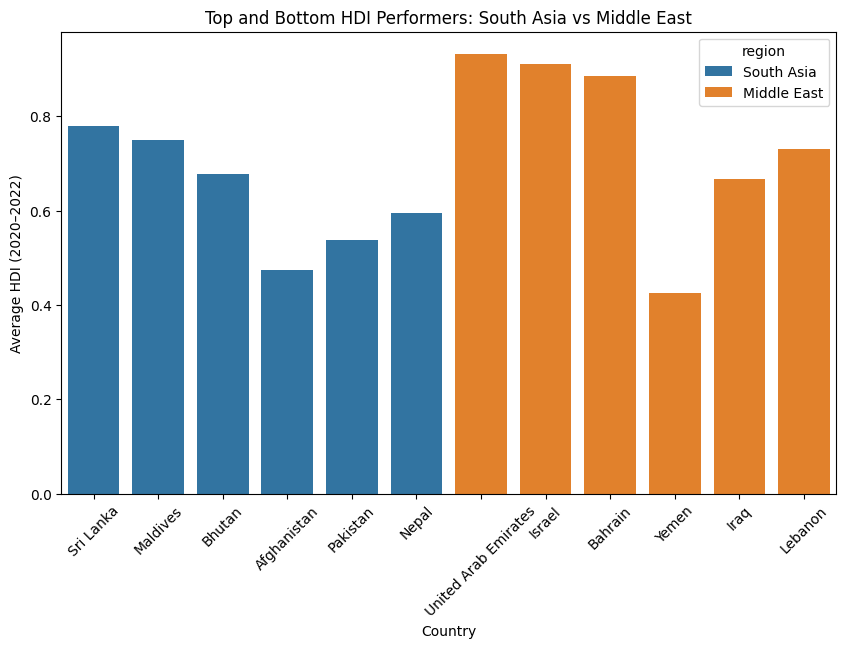

In [170]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=compare_df,
    x='country',
    y='hdi',
    hue='region'
)
plt.xlabel("Country")
plt.ylabel("Average HDI (2020–2022)")
plt.title("Top and Bottom HDI Performers: South Asia vs Middle East")
plt.xticks(rotation=45)
plt.show()


Task-4. Metric Comparisons

In [171]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

for col in metrics:
    sa_df[col] = pd.to_numeric(sa_df[col], errors='coerce')
    me_df[col] = pd.to_numeric(me_df[col], errors='coerce')

sa_mean_metrics = sa_df[metrics].mean().reset_index()
sa_mean_metrics['region'] = 'South Asia'

me_mean_metrics = me_df[metrics].mean().reset_index()
me_mean_metrics['region'] = 'Middle East'

metric_compare_df = pd.concat([sa_mean_metrics, me_mean_metrics])
metric_compare_df.columns = ['metric', 'value', 'region']


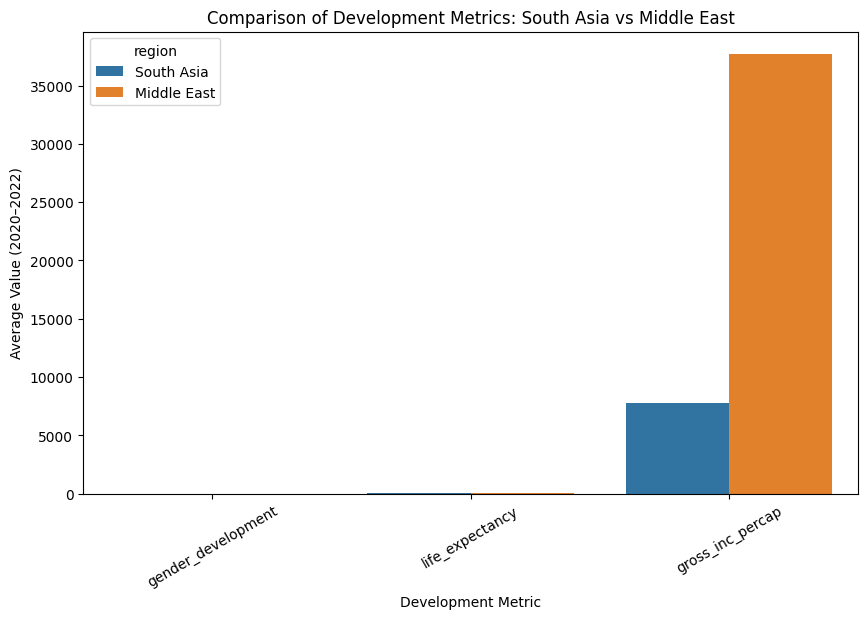

In [172]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=metric_compare_df,
    x='metric',
    y='value',
    hue='region'
)
plt.xlabel("Development Metric")
plt.ylabel("Average Value (2020–2022)")
plt.title("Comparison of Development Metrics: South Asia vs Middle East")
plt.xticks(rotation=30)
plt.show()


5. HDI Disparity:


In [173]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_max = sa_df['hdi'].max()
sa_min = sa_df['hdi'].min()
sa_range = sa_max - sa_min

me_max = me_df['hdi'].max()
me_min = me_df['hdi'].min()
me_range = me_max - me_min

sa_cv = sa_df['hdi'].std() / sa_df['hdi'].mean()
me_cv = me_df['hdi'].std() / me_df['hdi'].mean()

print("South Asia HDI Range:", sa_range)
print("South Asia HDI CV:", sa_cv)

print("Middle East HDI Range:", me_range)
print("Middle East HDI CV:", me_cv)


South Asia HDI Range: 0.321
South Asia HDI CV: 0.1536520924690084
Middle East HDI Range: 0.5130000000000001
Middle East HDI CV: 0.17910145193048382


Task-6. Corelation Analysis

In [174]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

cols = ['hdi', 'gender_development', 'life_expectancy']

for c in cols:
    sa_df[c] = pd.to_numeric(sa_df[c], errors='coerce')
    me_df[c] = pd.to_numeric(me_df[c], errors='coerce')

sa_df.dropna(subset=cols, inplace=True)
me_df.dropna(subset=cols, inplace=True)


In [175]:
sa_corr_gender = sa_df['hdi'].corr(sa_df['gender_development'])
sa_corr_life = sa_df['hdi'].corr(sa_df['life_expectancy'])

me_corr_gender = me_df['hdi'].corr(me_df['gender_development'])
me_corr_life = me_df['hdi'].corr(me_df['life_expectancy'])

print("South Asia - HDI vs Gender Development:", sa_corr_gender)
print("South Asia - HDI vs Life Expectancy:", sa_corr_life)

print("Middle East - HDI vs Gender Development:", me_corr_gender)
print("Middle East - HDI vs Life Expectancy:", me_corr_life)


South Asia - HDI vs Gender Development: 0.8742177004831327
South Asia - HDI vs Life Expectancy: 0.9387641385416623
Middle East - HDI vs Gender Development: 0.9356697525724119
Middle East - HDI vs Life Expectancy: 0.9331227568940162


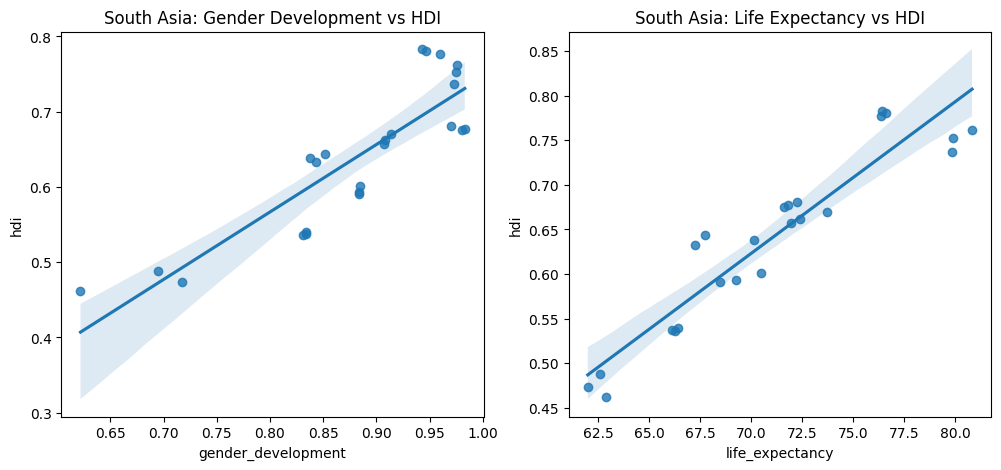

In [176]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x='gender_development', y='hdi', data=sa_df)
plt.title("South Asia: Gender Development vs HDI")

plt.subplot(1, 2, 2)
sns.regplot(x='life_expectancy', y='hdi', data=sa_df)
plt.title("South Asia: Life Expectancy vs HDI")

plt.show()


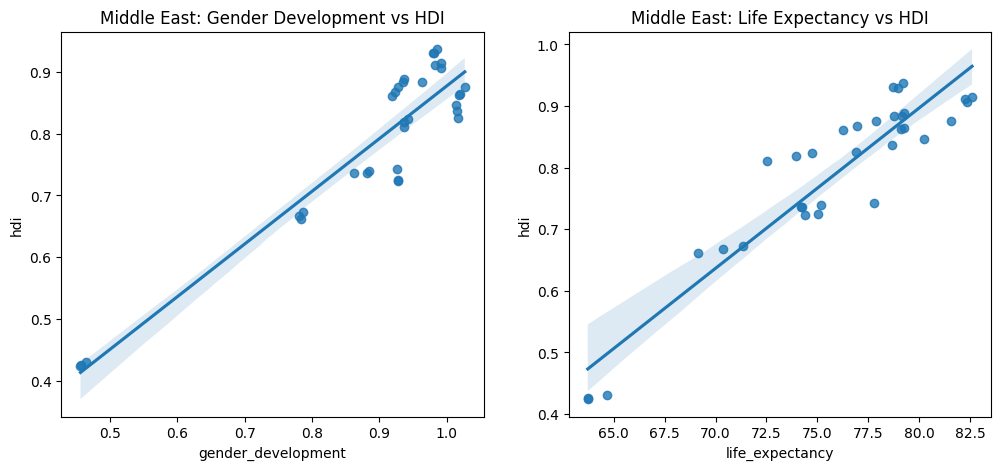

In [177]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x='gender_development', y='hdi', data=me_df)
plt.title("Middle East: Gender Development vs HDI")

plt.subplot(1, 2, 2)
sns.regplot(x='life_expectancy', y='hdi', data=me_df)
plt.title("Middle East: Life Expectancy vs HDI")

plt.show()


Task7. Outliner Detection

In [178]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

for df in [sa_df, me_df]:
    df['hdi'] = pd.to_numeric(df['hdi'], errors='coerce')
    df['gross_inc_percap'] = pd.to_numeric(df['gross_inc_percap'], errors='coerce')
    df.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

def detect_outliers(df):
    Q1_hdi, Q3_hdi = df['hdi'].quantile([0.25, 0.75])
    IQR_hdi = Q3_hdi - Q1_hdi

    Q1_gni, Q3_gni = df['gross_inc_percap'].quantile([0.25, 0.75])
    IQR_gni = Q3_gni - Q1_gni

    return df[
        (df['hdi'] < Q1_hdi - 1.5 * IQR_hdi) |
        (df['hdi'] > Q3_hdi + 1.5 * IQR_hdi) |
        (df['gross_inc_percap'] < Q1_gni - 1.5 * IQR_gni) |
        (df['gross_inc_percap'] > Q3_gni + 1.5 * IQR_gni)
    ]

sa_outliers = detect_outliers(sa_df)
me_outliers = detect_outliers(me_df)

print("South Asia Outliers:")
print(sa_outliers[['country', 'hdi', 'gross_inc_percap']])

print("\nMiddle East Outliers:")
print(me_outliers[['country', 'hdi', 'gross_inc_percap']])

South Asia Outliers:
Empty DataFrame
Columns: [country, hdi, gross_inc_percap]
Index: []

Middle East Outliers:
   country    hdi  gross_inc_percap
30   Yemen  0.430       1152.015672
31   Yemen  0.425       1112.162989
32   Yemen  0.424       1105.763435


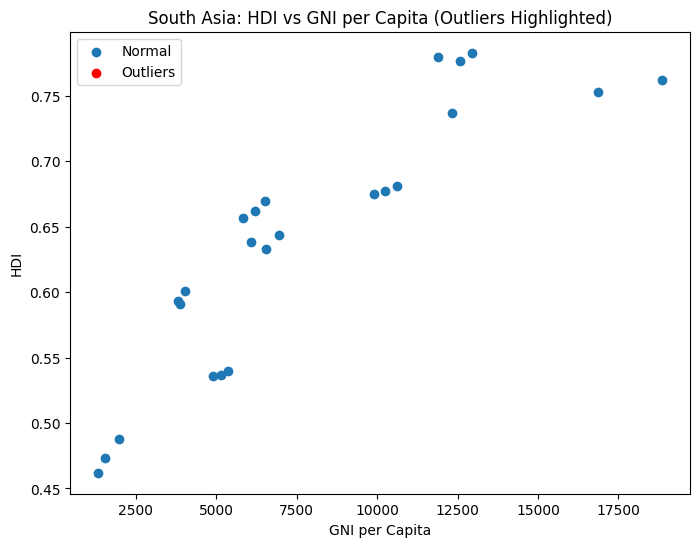

In [179]:
plt.figure(figsize=(8, 6))
plt.scatter(sa_df['gross_inc_percap'], sa_df['hdi'], label='Normal')
plt.scatter(sa_outliers['gross_inc_percap'], sa_outliers['hdi'], color='red', label='Outliers')
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("South Asia: HDI vs GNI per Capita (Outliers Highlighted)")
plt.legend()
plt.show()


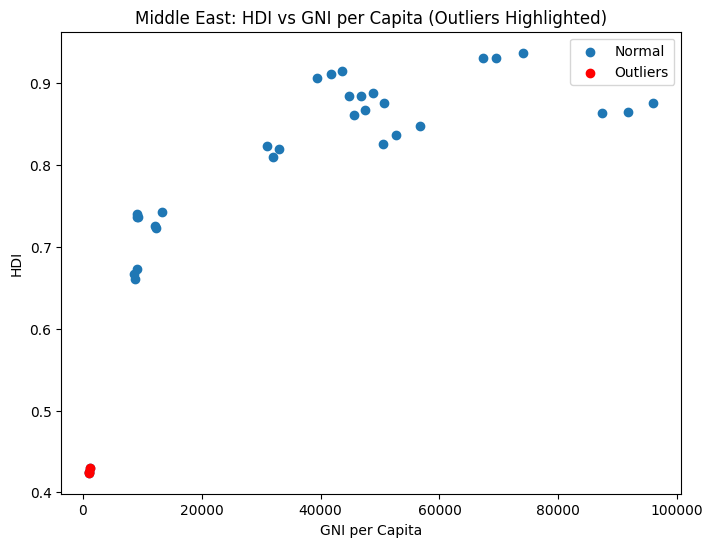

In [180]:
plt.figure(figsize=(8, 6))
plt.scatter(me_df['gross_inc_percap'], me_df['hdi'], label='Normal')
plt.scatter(me_outliers['gross_inc_percap'], me_outliers['hdi'], color='red', label='Outliers')
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Middle East: HDI vs GNI per Capita (Outliers Highlighted)")
plt.legend()
plt.show()
